# Experimenting with variations to LeNet's architecture
This is an attempt to improve the score at CIFAR-10

In [1]:
from tensorflow.keras import Sequential, layers, Model, callbacks
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow import pad, expand_dims, cast, float32, int32
from tensorflow.config import list_physical_devices
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

In [2]:
model_statistics = {}

# Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

y_train = cast(y_train, int32)
y_test = cast(y_test, int32)

x_train = cast(x_train, float32) / 255.0
x_test = cast(x_test, float32) / 255.0

x_val = x_train[:10000]
y_val = y_train[:10000]

x_train = x_train[10000:]
y_train = y_train[10000:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


# Callbacks

In [4]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=10
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Base Implementation (to test against)

## Definition

In [22]:
class LeNet(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 3))
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh')
        self.pool4 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(5, 5), activation='tanh')
        self.flat6 = layers.Flatten()
        self.dense7 = layers.Dense(units=84, activation='tanh')
        self.dense8 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool4(x)
        x = self.conv5(x)
        x = self.flat6(x)
        x = self.dense7(x)
        x = self.dense8(x)

        return x

In [23]:
base = LeNet()
base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
base.summary()

Model: "le_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [24]:
history = base.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3554 - loss: 1.8228 - val_accuracy: 0.3851 - val_loss: 1.7286 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4308 - loss: 1.6098 - val_accuracy: 0.4638 - val_loss: 1.5124 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4816 - loss: 1.4630 - val_accuracy: 0.4881 - val_loss: 1.4315 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5306 - loss: 1.3253 - val_accuracy: 0.5281 - val_loss: 1.3233 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5497 - loss: 1.2697 - val_accuracy: 0.5284 - val_loss: 1.3192 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5662 - loss: 1.2264 - val_accuracy: 0.5424 - val_loss: 1.2772 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step -

In [25]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [26]:
model_statistics["LeNet Base"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": base.count_params(),
}

# Test 1: Replacing tanh with ReLU
The AlexNet paper mentions that deeper neural networks converge faster with ReLU as compared to tanh. Even if the current architecture doesn't benefit from this, it would still help in the later tests considerably.

## Definition

In [27]:
class LeNet_E1(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal", input_shape=(32, 32, 3))
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal")
        self.pool4 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(5, 5), activation='relu', kernel_initializer="he_normal")
        self.flat6 = layers.Flatten()
        self.dense7 = layers.Dense(units=84, activation='relu', kernel_initializer="he_normal")
        self.dense8 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool4(x)
        x = self.conv5(x)
        x = self.flat6(x)
        x = self.dense7(x)
        x = self.dense8(x)

        return x

In [28]:
e1 = LeNet_E1()
e1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e1.summary()

Model: "le_net_e1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [29]:
history = e1.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4066 - loss: 1.6259 - val_accuracy: 0.4789 - val_loss: 1.4360 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5080 - loss: 1.3736 - val_accuracy: 0.5286 - val_loss: 1.3170 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5472 - loss: 1.2694 - val_accuracy: 0.5493 - val_loss: 1.2744 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5898 - loss: 1.1527 - val_accuracy: 0.5749 - val_loss: 1.1933 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6081 - loss: 1.1040 - val_accuracy: 0.5772 - val_loss: 1.2041 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6233 - loss: 1.0626 - val_accuracy: 0.5812 - val_loss: 1.1733 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - a

In [30]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [31]:
model_statistics["LeNet E1"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e1.count_params(),
}

Well that was unexpected. It increased the accuracy.

# Test 2: Reducing Conv Kernel Size
VGG uses 2x Conv with 3x3 kernel size instead of 1 with 5x5 size to reduce parameters and improve accuracy. Let's try that.

## Definition

In [32]:
class LeNet_E2(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same")
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [33]:
e2 = LeNet_E2()
e2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e2.summary()

Model: "le_net_e2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [34]:
history = e2.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4371 - loss: 1.5474 - val_accuracy: 0.5376 - val_loss: 1.2685 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5953 - loss: 1.1421 - val_accuracy: 0.6254 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6675 - loss: 0.9437 - val_accuracy: 0.6724 - val_loss: 0.9560 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7538 - loss: 0.7023 - val_accuracy: 0.6978 - val_loss: 0.8738 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7924 - loss: 0.5940 - val_accuracy: 0.7007 - val_loss: 0.9007 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8248 - loss: 0.4945 - val_accuracy: 0.7055 - val_loss: 0.9397 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step -

In [35]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [36]:
model_statistics["LeNet E2"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e2.count_params(),
}

# Test 3: Adding Batch Normalization
Batch Normalization is a technique to reduce overfitting.

## Definition

In [37]:
class LeNet_E3(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=6, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [38]:
e3 = LeNet_E3()
e3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e3.summary()

Model: "le_net_e3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [39]:
history = e3.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4448 - loss: 1.5258 - val_accuracy: 0.5559 - val_loss: 1.2283 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6009 - loss: 1.1269 - val_accuracy: 0.6305 - val_loss: 1.0367 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6736 - loss: 0.9322 - val_accuracy: 0.6661 - val_loss: 0.9580 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7571 - loss: 0.6956 - val_accuracy: 0.7000 - val_loss: 0.8880 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7995 - loss: 0.5797 - val_accuracy: 0.7005 - val_loss: 0.9054 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8344 - loss: 0.4767 - val_accuracy: 0.6950 - val_loss: 0.9614 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step -

In [40]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [41]:
model_statistics["LeNet E3"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e3.count_params(),
}

# Test 4: Increasing the number of filters
Increasing the number of filters should help capture more features

## Definition

In [42]:
class LeNet_E4(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.AveragePooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [43]:
e4 = LeNet_E4()
e4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e4.summary()

Model: "le_net_e4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [44]:
history = e4.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4624 - loss: 1.4784 - val_accuracy: 0.5955 - val_loss: 1.1434 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6552 - loss: 0.9806 - val_accuracy: 0.6871 - val_loss: 0.8972 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7184 - loss: 0.8022 - val_accuracy: 0.7260 - val_loss: 0.7998 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8034 - loss: 0.5609 - val_accuracy: 0.7493 - val_loss: 0.7304 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8404 - loss: 0.4544 - val_accuracy: 0.7533 - val_loss: 0.7402 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8738 - loss: 0.3588 - val_accuracy: 0.7678 - val_loss: 0.7561 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - 

In [45]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [46]:
model_statistics["LeNet E4"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e4.count_params(),
}

# Test 5: Replacing AveragePooling2D with MaxPooling2D
MaxPooling2D is more efficient than AveragePooling2D.

## Definition

In [47]:
class LeNet_E5(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [48]:
e5 = LeNet_E5()
e5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e5.summary()

Model: "le_net_e5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [49]:
history = e5.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4528 - loss: 1.5073 - val_accuracy: 0.5962 - val_loss: 1.1482 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6511 - loss: 1.0010 - val_accuracy: 0.6733 - val_loss: 0.9367 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7118 - loss: 0.8288 - val_accuracy: 0.6749 - val_loss: 0.9642 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7916 - loss: 0.5989 - val_accuracy: 0.7422 - val_loss: 0.7586 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8268 - loss: 0.4918 - val_accuracy: 0.7470 - val_loss: 0.7804 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8596 - loss: 0.4016 - val_accuracy: 0.7434 - val_loss: 0.8466 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - 

In [50]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [51]:
model_statistics["LeNet E5"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e5.count_params(),
}

This was a little disappointing but the accuracy is within margin of error.

# Test 6: Adding dropouts
The issue previously was the training accuracy hitting 1 near the end of each training session, which is a sign of overfitting, dropout should help reduce that.

## Definiton

In [52]:
class LeNet_E6(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=120, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [53]:
e6 = LeNet_E6()
e6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e6.summary()

Model: "le_net_e6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_68 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [54]:
history = e6.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4520 - loss: 1.5031 - val_accuracy: 0.5366 - val_loss: 1.3502 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6257 - loss: 1.0468 - val_accuracy: 0.6248 - val_loss: 1.0538 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6787 - loss: 0.9063 - val_accuracy: 0.6320 - val_loss: 1.0682 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7330 - loss: 0.7551 - val_accuracy: 0.7024 - val_loss: 0.8421 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7490 - loss: 0.7028 - val_accuracy: 0.7378 - val_loss: 0.7467 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7630 - loss: 0.6680 - val_accuracy: 0.7364 - val_loss: 0.7478 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step -

In [55]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [56]:
model_statistics["LeNet E6"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e6.count_params(),
}

Amazing.

# Test 7: Just One More Convolve Layer Bro


## Definition

In [57]:
class LeNet_E7(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dense2(x)

        return x

In [58]:
e7 = LeNet_E7()
e7.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e7.summary()

Model: "le_net_e7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [59]:
history = e7.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.4601 - loss: 1.4718 - val_accuracy: 0.5717 - val_loss: 1.2159 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6314 - loss: 1.0418 - val_accuracy: 0.5973 - val_loss: 1.1399 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6849 - loss: 0.8946 - val_accuracy: 0.6880 - val_loss: 0.8960 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7372 - loss: 0.7419 - val_accuracy: 0.7113 - val_loss: 0.8077 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7586 - loss: 0.6882 - val_accuracy: 0.7121 - val_loss: 0.7945 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7683 - loss: 0.6528 - val_accuracy: 0.7694 - val_loss: 0.6611 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - 

In [60]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [61]:
model_statistics["LeNet E7"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e7.count_params(),
}

Though this has gone deeper than planned, I want to get closer to 90% accuracy.

# Test 8: Dropout before dense layer

## Definition

In [62]:
class LeNet_E8(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.flat1 = layers.Flatten()
        self.dense1 = layers.Dense(units=84, activation='relu', kernel_initializer='he_normal')
        self.dropout4 = layers.Dropout(0.4)
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.flat1(x)
        x = self.dense1(x)
        x = self.dropout4(x, training=training)
        x = self.dense2(x)

        return x

In [63]:
e8 = LeNet_E8()
e8.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e8.summary()

Model: "le_net_e8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_82 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
history = e8.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.2621 - loss: 1.9062 - val_accuracy: 0.3436 - val_loss: 1.7254 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3832 - loss: 1.6179 - val_accuracy: 0.4683 - val_loss: 1.4935 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4747 - loss: 1.4236 - val_accuracy: 0.5616 - val_loss: 1.2515 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5430 - loss: 1.2506 - val_accuracy: 0.6381 - val_loss: 1.0394 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5864 - loss: 1.1603 - val_accuracy: 0.6552 - val_loss: 0.9937 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6174 - loss: 1.0862 - val_accuracy: 0.6681 - val_loss: 0.9202 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step

In [65]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [66]:
model_statistics["LeNet E8"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e8.count_params(),
}

# Test 9: Global Average Pooling Instead of dense layer

## Definition

In [67]:
class LeNet_E9(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.gap1 = layers.GlobalAveragePooling2D()
        self.dense2 = layers.Dense(units=10, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.gap1(x)
        x = self.dense2(x)

        return x

In [68]:
e9 = LeNet_E9()
e9.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e9.summary()

Model: "le_net_e9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [69]:
history = e9.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5075 - loss: 1.3647 - val_accuracy: 0.5474 - val_loss: 1.3400 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6369 - loss: 1.0242 - val_accuracy: 0.6012 - val_loss: 1.1534 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6845 - loss: 0.8970 - val_accuracy: 0.6637 - val_loss: 0.9701 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7324 - loss: 0.7689 - val_accuracy: 0.7477 - val_loss: 0.7211 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7437 - loss: 0.7305 - val_accuracy: 0.7443 - val_loss: 0.7354 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7566 - loss: 0.6908 - val_accuracy: 0.7600 - val_loss: 0.6867 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step -

In [70]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [71]:
model_statistics["LeNet E9"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e9.count_params(),
}

# Test 10: Adding a final convolution layer

## Definition

In [16]:
class LeNet_E10(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(32, 32, 3))
        self.conv2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same")
        self.bn1 = layers.BatchNormalization()
        self.activation1 = layers.Activation('relu')
        self.pool1 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout1 = layers.Dropout(0.2)
        self.conv3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.conv4 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same")
        self.bn2 = layers.BatchNormalization()
        self.activation2 = layers.Activation('relu')
        self.pool2 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout2 = layers.Dropout(0.2)
        self.conv5 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.conv6 = layers.Conv2D(filters=96, kernel_size=(3, 3), padding="same")
        self.bn3 = layers.BatchNormalization()
        self.activation3 = layers.Activation('relu')
        self.pool3 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout3 = layers.Dropout(0.2)
        self.conv7 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.conv8 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same")
        self.bn4 = layers.BatchNormalization()
        self.activation4 = layers.Activation('relu')
        self.pool4 = layers.MaxPooling2D((2, 2), strides=2)
        self.dropout4 = layers.Dropout(0.2)
        self.conv9 = layers.Conv2D(filters=10, kernel_size=1, padding="same")
        self.gap1 = layers.GlobalAveragePooling2D()
        self.activation6 = layers.Activation('softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.pool2(x)
        x = self.dropout2(x, training=training)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.bn3(x)
        x = self.activation3(x)
        x = self.pool3(x)
        x = self.dropout3(x, training=training)
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.bn4(x)
        x = self.activation4(x)
        x = self.pool4(x)
        x = self.dropout4(x, training=training)
        x = self.conv9(x)
        x = self.gap1(x)
        x = self.activation6(x)

        return x

In [17]:
e10 = LeNet_E10()
e10.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
e10.summary()

Model: "le_net_e10_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [18]:
history = e10.fit(
    x_train, y_train,
    epochs=100,
    callbacks=[early_stopping, reduce_lr],
    validation_data=(x_val, y_val)
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5033 - loss: 1.3772 - val_accuracy: 0.5148 - val_loss: 1.5118 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6386 - loss: 1.0216 - val_accuracy: 0.5610 - val_loss: 1.3015 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6876 - loss: 0.8875 - val_accuracy: 0.6877 - val_loss: 0.8852 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7378 - loss: 0.7524 - val_accuracy: 0.7537 - val_loss: 0.6960 - learning_rate: 5.0000e-04
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7502 - loss: 0.7145 - val_accuracy: 0.7708 - val_loss: 0.6502 - learning_rate: 5.0000e-04
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7619 - loss: 0.6765 - val_accuracy: 0.7274 - val_loss: 0.7896 - learning_rate: 5.0000e-04
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - 

In [19]:
e10.count_params()

464874

In [20]:
print(f"Converged at epoch {early_stopping.stopped_epoch - early_stopping.patience}")

Converged at epoch 9


In [21]:
model_statistics["LeNet E10"] = {
    "history": history,
    "convergence": early_stopping.stopped_epoch - early_stopping.patience,
    "parameters": e10.count_params(),
}

# Measuring Accuracy

In [72]:
loss, accuracy = base.evaluate(x_test, y_test)
model_statistics["LeNet Base"]["test_loss"] = loss
model_statistics["LeNet Base"]["test_accuracy"] = accuracy

loss, accuracy = e1.evaluate(x_test, y_test)
model_statistics["LeNet E1"]["test_loss"] = loss
model_statistics["LeNet E1"]["test_accuracy"] = accuracy

loss, accuracy = e2.evaluate(x_test, y_test)
model_statistics["LeNet E2"]["test_loss"] = loss
model_statistics["LeNet E2"]["test_accuracy"] = accuracy

loss, accuracy = e3.evaluate(x_test, y_test)
model_statistics["LeNet E3"]["test_loss"] = loss
model_statistics["LeNet E3"]["test_accuracy"] = accuracy

loss, accuracy = e4.evaluate(x_test, y_test)
model_statistics["LeNet E4"]["test_loss"] = loss
model_statistics["LeNet E4"]["test_accuracy"] = accuracy

loss, accuracy = e5.evaluate(x_test, y_test)
model_statistics["LeNet E5"]["test_loss"] = loss
model_statistics["LeNet E5"]["test_accuracy"] = accuracy

loss, accuracy = e6.evaluate(x_test, y_test)
model_statistics["LeNet E6"]["test_loss"] = loss
model_statistics["LeNet E6"]["test_accuracy"] = accuracy

loss, accuracy = e7.evaluate(x_test, y_test)
model_statistics["LeNet E7"]["test_loss"] = loss
model_statistics["LeNet E7"]["test_accuracy"] = accuracy

loss, accuracy = e8.evaluate(x_test, y_test)
model_statistics["LeNet E8"]["test_loss"] = loss
model_statistics["LeNet E8"]["test_accuracy"] = accuracy

loss, accuracy = e9.evaluate(x_test, y_test)
model_statistics["LeNet E9"]["test_loss"] = loss
model_statistics["LeNet E9"]["test_accuracy"] = accuracy

loss, accuracy = e10.evaluate(x_test, y_test)
model_statistics["LeNet E10"]["test_loss"] = loss
model_statistics["LeNet E10"]["test_accuracy"] = accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5552 - loss: 1.2473
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6029 - loss: 1.1472
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6950 - loss: 1.6766
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6904 - loss: 1.8941
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7633 - loss: 1.5551
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7523 - loss: 1.5928
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7848 - loss: 0.6254
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8088 - loss: 0.5481
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7446 - loss: 0.7274
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8054 - loss: 0.5553
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8124 - loss: 0.5436


# Plotting Results

In [73]:
from matplotlib import cm

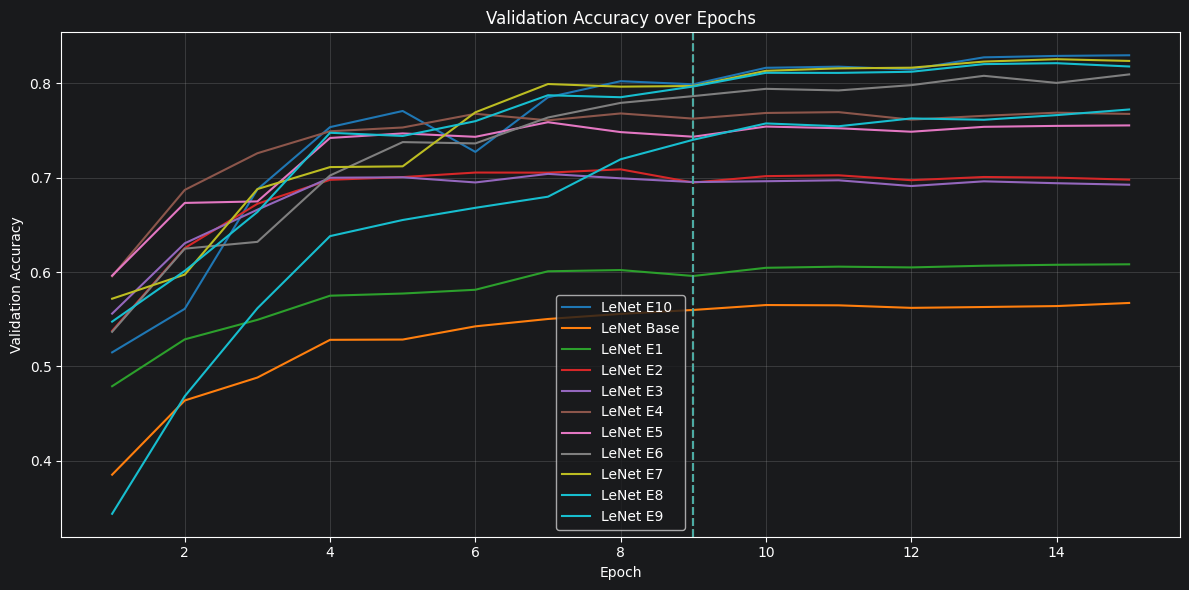

In [74]:
colors = cm.tab10(np.linspace(0, 1, len(model_statistics)))

fig, ax = plt.subplots(figsize=(12, 6))

for (name, stats), color in zip(model_statistics.items(), colors):
    val_acc = stats["history"].history["val_accuracy"]
    epochs  = range(1, len(val_acc) + 1)
    ax.plot(epochs, val_acc, label=name, color=color)
    ax.axvline(stats["convergence"], color=color, linestyle="--", alpha=0.4)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy over Epochs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

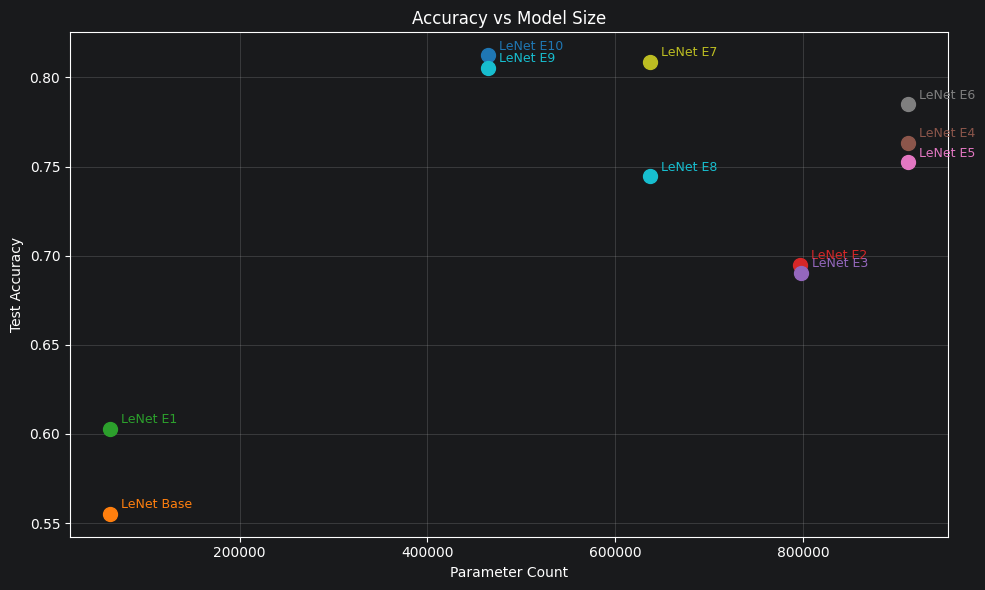

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))

for (name, stats), color in zip(model_statistics.items(), colors):
    final_acc = stats["test_accuracy"]
    params    = stats["parameters"]
    ax.scatter(params, final_acc, color=color, s=100, zorder=5)
    ax.annotate(name, (params, final_acc), textcoords="offset points", xytext=(8, 4), fontsize=9, color=color)

ax.set_xlabel("Parameter Count")
ax.set_ylabel("Test Accuracy")
ax.set_title("Accuracy vs Model Size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
for name, stats in model_statistics.items():
    print(f"{name} - Parameters: {stats['parameters']}, Convergence: {stats['convergence']}")
    print(f"Test Accuracy: {stats['test_accuracy']}, Test Loss: {stats['test_loss']}")
    print("\n")

LeNet E10 - Parameters: 464874, Convergence: 9
Test Accuracy: 0.8123999834060669, Test Loss: 0.5435667037963867


LeNet Base - Parameters: 62006, Convergence: 9
Test Accuracy: 0.5551999807357788, Test Loss: 1.247253179550171


LeNet E1 - Parameters: 62006, Convergence: 9
Test Accuracy: 0.6029000282287598, Test Loss: 1.1472045183181763


LeNet E2 - Parameters: 796872, Convergence: 9
Test Accuracy: 0.6949999928474426, Test Loss: 1.6766057014465332


LeNet E3 - Parameters: 797440, Convergence: 9
Test Accuracy: 0.6904000043869019, Test Loss: 1.8941081762313843


LeNet E4 - Parameters: 911446, Convergence: 9
Test Accuracy: 0.7633000016212463, Test Loss: 1.555099368095398


LeNet E5 - Parameters: 911446, Convergence: 9
Test Accuracy: 0.7523000240325928, Test Loss: 1.592849850654602


LeNet E6 - Parameters: 911446, Convergence: 9
Test Accuracy: 0.7847999930381775, Test Loss: 0.6254072189331055


LeNet E7 - Parameters: 636550, Convergence: 9
Test Accuracy: 0.8087999820709229, Test Loss: 0.5481